In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import logging

from tools.robots.robot import Robot
from tools.robots.double_integrator import DoubleIntegrator
from tools.robots.single_integrator import SingleIntegrator

from tools.planners.mcgs import MCGSPlanner, NodePayload, EdgePayload
from tools.envs.frozen_lake_continuous import FrozenLakeEnv

from tools.utils.plot_graph import plot_graph_2d, plot_spacetime_graph_3d, plot_graph_2d_live

import rustworkx as rx
from rustworkx.visualization import mpl_draw
# from rustworkx import Pos2DMapping
%matplotlib widget
%matplotlib inline


In [2]:
# only from mcgs.py
logging.basicConfig(level=logging.WARNING, format='%(asctime)s - %(levelname)s - %(message)s')


In [3]:
def reward_function(state):
    # Example reward function: negative distance to the goal position
    goal_position = 10*np.array([1.0, 1.0])  # Define goal position
    return 0 - 1*state['time'] - np.linalg.norm(state['position'] - goal_position, ord=2)

# def reward_function(state):
#     # Example reward function: negative distance to the goal position
#     goal_position = 10*np.array([1.0, 1.0])  # Define goal position
#     return - np.linalg.norm(state['position'] - goal_position, ord=2)




In [4]:
max_velocity = 1.0
rob = SingleIntegrator(id=0, 
                       name="SingleIntegrator", 
                       dt=1.0, 
                       max_velocity=max_velocity,
                       state_goal={'position': 10*np.array([1.0, 1.0]), 
                                   'time': np.array(20.0)},
                       action_sampler_method='uniform',)

root_state = {'position': np.array([0.0, 0.0]), 
              'time': np.array(0.0)}

rob.state = root_state
print(rob)

root_encoded_state = rob.encode_state(root_state)
print("Encoded root state:", root_encoded_state)
print("Encoded goal state:", rob.encode_state(rob.state_goal))


Robot SingleIntegrator (ID: 0) with state {'position': array([0., 0.]), 'time': array(0.)} and bounding box None
Encoded root state: [0. 0. 0.]
Encoded goal state: [10. 10. 20.]


In [5]:
# max_velocity = 1.0
# max_acceleration = 1.0
# rob = DoubleIntegrator(id=0, 
#                        name="DoubleIntegrator", 
#                        dt=1.0, 
#                        max_velocity=max_velocity,
#                        max_acceleration=max_acceleration,
#                        state_goal={'position': 10*np.array([1.0, 1.0]), 
#                                    'velocity': 0*np.array([1.0, 1.0]),
#                                    'time': np.array(20.0)},
#                        action_sampler_method='uniform',)

# root_state = {'position': np.array([0.0, 0.0]),
#               'velocity': np.array([0.0, 0.0]), 
#               'time': np.array(0.0)}

# rob.state = root_state
# print(rob)

# root_encoded_state = rob.encode_state(root_state)
# print("Encoded root state:", root_encoded_state)
# print("Encoded goal state:", rob.encode_state(rob.state_goal))


In [6]:
# MCGS Planner
mcgs_planner = MCGSPlanner(robot=rob, 
                        reward_function=reward_function,
                        max_iterations=100, 
                        expand_n_times=4,
                        kappa=1.6,
                        alpha=1.0,
                        k=8,
                        radius_threshold=1.8,
                        c_uct=0.3)

# MCTS Planner

# mcgs_planner = MCGSPlanner(robot=rob, 
#                         reward_function=reward_function,
#                         max_iterations=100, 
#                         kappa=1.8, 
#                         alpha=.8,
#                         k=0,
#                         radius_threshold=0.0,
#                         c_uct=0.8)

In [7]:
mcgs_planner.reset_graph()
mcgs_planner.plan(iterations=30)


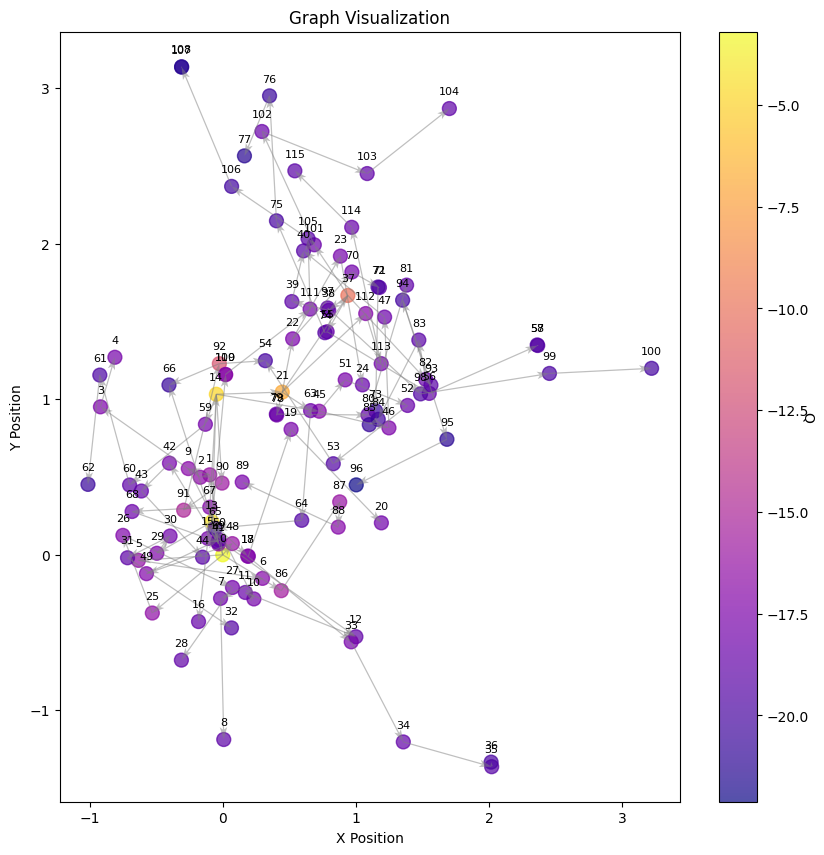

<Figure size 640x480 with 0 Axes>

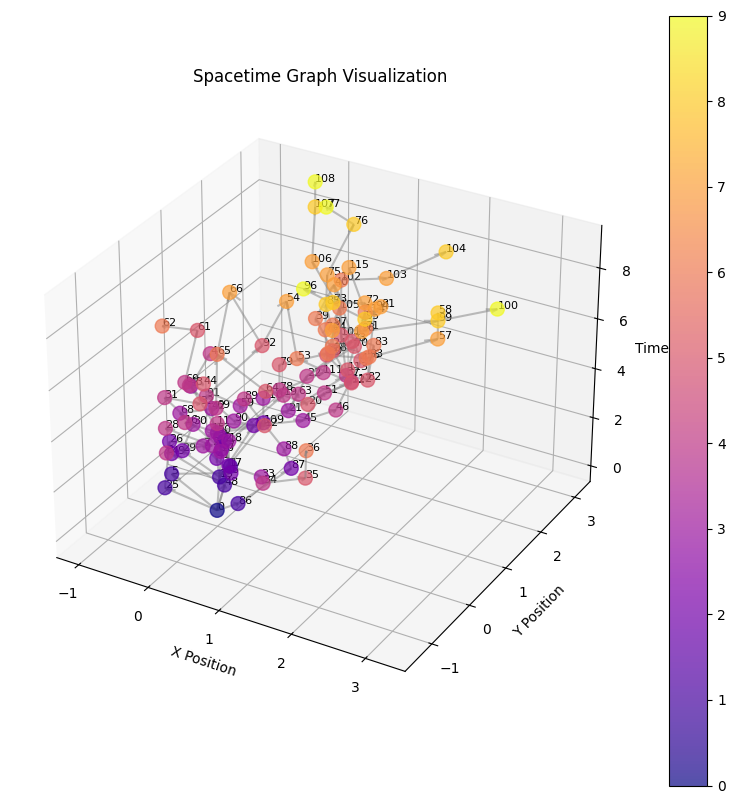

In [8]:
plot_graph_2d(mcgs_planner.graph, plot_labels=True, scatter_mode='Q', plot_values=False, bbox=None)
plot_spacetime_graph_3d(mcgs_planner.graph, mcgs_planner.robot, plot_labels=True, plot_time=True)

In [9]:
atol = 0.0
rtol = .2

plan = mcgs_planner.yield_plan(atol=atol, rtol=rtol)
print(plan)
print(mcgs_planner.graph[plan[-1]].state)
print("Finished: ", rob.is_finished(atol=atol, rtol=rtol, state=mcgs_planner.graph[plan[-1]].state))

[0, 13, 14, 21, 37, 101, 105, 106, 107, 108]
{'position': array([-0.30891663,  3.13786501]), 'time': np.float64(9.0)}
Finished:  False


In [10]:
mcgs_planner.reset_graph()


In [11]:
def step(action: EdgePayload):
    current_state = mcgs_planner.robot.state
    mcgs_planner.robot.step(action.action + 0.1 *np.random.normal(0, 1, size=action.action.shape))
    new_state = mcgs_planner.robot.state
    print("Current state:", current_state)
    print("New state:", new_state)

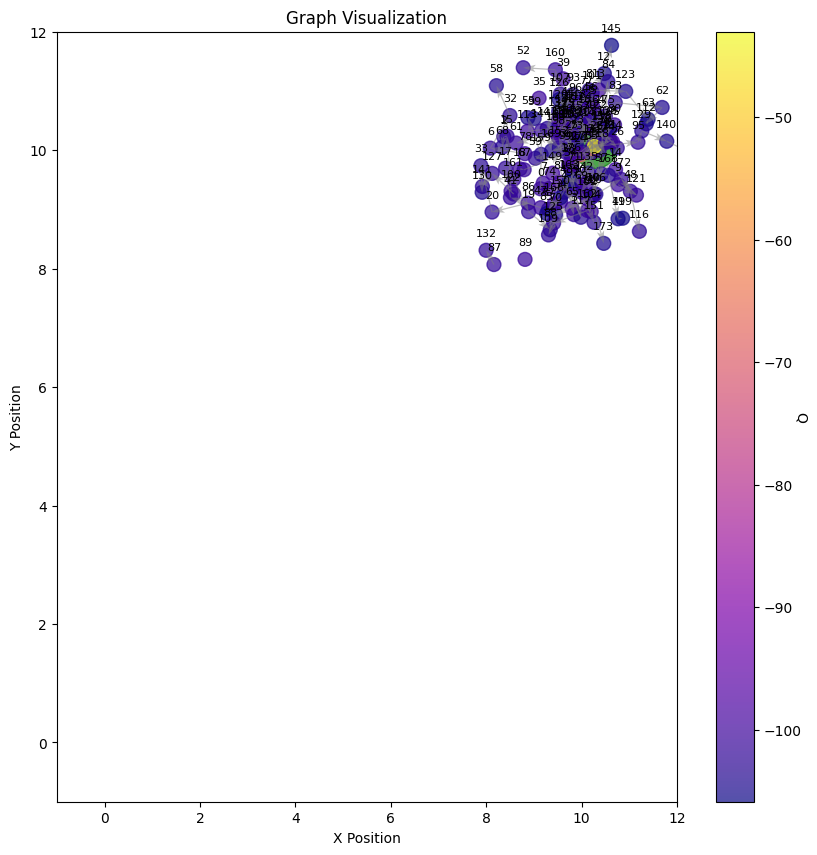

<Figure size 640x480 with 0 Axes>

Current state: {'position': array([10.2745142 , 10.06587312]), 'time': np.float64(99.0)}
New state: {'position': array([ 9.82559095, 10.03482419]), 'time': np.float64(100.0)}
New node: 114 with successors:  NodeIndices[]


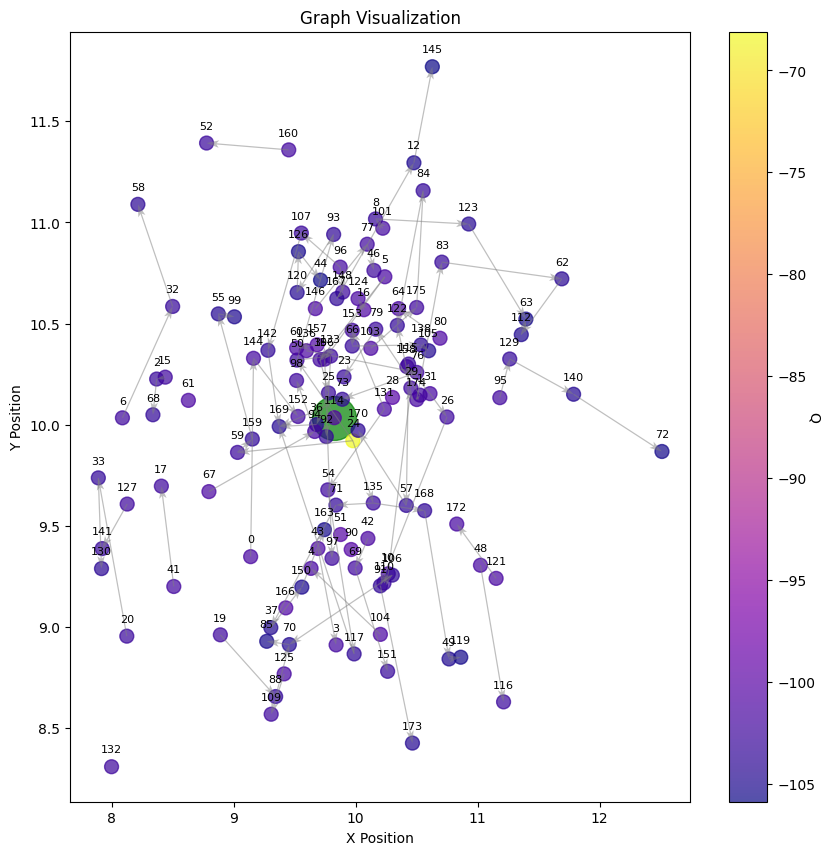

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
mcgs_planner.reset_graph()


atol = 0.0
rtol = .1

for i in range(100):
    print("Iteration:", i)

    mcgs_planner.plan(iterations=10)
    
    plan = mcgs_planner.yield_plan(atol=atol, rtol=rtol)
    print(plan)
    assert len(plan) > 1, "Plan does not include successor node!"
    optimal_action = mcgs_planner.graph.get_edge_data(mcgs_planner.root_node_id, plan[1])
    print("Optimal action:", optimal_action.action, " from ", mcgs_planner.root_node_id, " to ", plan[1], " at ", mcgs_planner.graph[plan[1]].state)
    # plot_graph_2d(mcgs_planner.graph, plot_labels=True, scatter_mode='Q', plot_values=False, robot=mcgs_planner.robot)
    fig = plot_graph_2d_live(mcgs_planner.graph, plot_labels=True, scatter_mode='Q', plot_values=False, robot=mcgs_planner.robot)
    step(optimal_action)
    mcgs_planner.update_planner()
    print("New node:", mcgs_planner.root_node_id, "with successors: ", mcgs_planner.graph.successor_indices(mcgs_planner.root_node_id))
    mcgs_planner.garbage_collector.collect_garbage(timestamp_threshold=mcgs_planner.robot.state['time'], root_node_id=mcgs_planner.root_node_id)
    if mcgs_planner.robot.is_finished(atol=atol, rtol=rtol, state=mcgs_planner.graph[mcgs_planner.root_node_id].state):
        print(f"Robot has reached the goal state after {i} iterations!")
        break

plot_graph_2d(mcgs_planner.graph, plot_labels=True, scatter_mode='Q', plot_values=False, robot=mcgs_planner.robot)